# Project 03: Gibbs Sampling (Random Algorithm)

In [1]:
import random
import numpy as np
import bamnostic as bs
import seqlogo as sl

#import function for building sequence motif & identifying seqs matching to motif
from data_readers import *
from project03 import motif_ops, data_readers
from seq_ops import get_seq
from motif_ops import *
from time import time

---
## Implement Gibbs Sampler


Gibbs sampling is a MCMC approach to identify enrichments. Here we will implement a method to identify motifs from a set of regions. 

Important considerations:
- We will need to score each sequence with a PWM using the `score_kmer()` or `score_sequence()` functions
    - You will need to investigate into the help documenation and libraries to identify how best to use these functions. 
- These sites are often not strand-specific and so both scores on the negative as well as positive strand should be considered
- To select a random sequence, use `random.randint()` or `numpy.random.randint()`
- To select a new position $m$ (as defined below) use `random.choices()` or `numpy.random.choice()`  

Assumptions: 
- We know $k$ as the length of expected motif
- Each sequence contains the motif



```
GibbsMotifFinder(DNA, k-length)
    random pick of k-length sequences from each line of DNA as Motifs
    for j ← 1 to 10000 or Motifs stops changing
        i ← Random(N) where N is number of DNA entries
        PWM ← PWM constructed from all Motifs except for Motifi
        Motifi ← select position m from PWM-scored k-mers in DNAi in probabilistic fashion from score distribution
    return PFM
```

Probability of chosing position $m = \frac{A_{m}}{\sum_{l}A_{l}}$ for positions $l$ in DNAi


**Note:** I have also added a function to `motif_ops.py` that will calculate the information content of your motifs. This is useful to observe the progression of your Gibbs sampler as well as a measure of convergence. You can use this function as `IC = pfm_ic(pfm)`. You should expect a slow increase of IC until it plateaus such as in the plot below from your lecture slides:

<center><img src='figures/Gibbs_Sampling.png'/ width=600px></center>

---
# Project Start

In [11]:
def GibbsMotifFinder (seqs, k, seed=None):
    '''
    Function to find a pfm from a list of strings using a Gibbs sampler
    
    Args: 
        seqs (str list): a list of sequences, not necessarily in same lengths
        k (int): the length of motif to find
        seed (int, default=None): seed for np.random

    Returns:
        pfm (numpy array): dimensions are 4xlength
    '''
    # Use rng to make random samples/selections/numbers
    # Example: randint = rng.integer(1, 10)
    random.seed(seed)
    rng = np.random.default_rng(seed)

    # make every sequence uppercase to work with score_kmer, initialize motifs list, and start counting time
    seqs = [s.upper() for s in seqs]
    motifs = []
    start_time = time()

    # choose random k-mer from each sequence and keep in a list
    for seq in seqs:
        start = rng.integers(0, len(seq) - k + 1)
        motifs.append(seq[start:start + k])

    #start a count for how many rounds the motif stays the same
    unchanged = 0

    # repeat update step up to 10,000 times or until convergence is achieved
    for j in range(10000):
        #pick a random sequence number between 0 and the last sequence 
        randint = rng.integers(0,len(seqs))

        # Exclude selected motif from the list then calculate pfm and pwm
        motifs_excluded = motifs[:randint] + motifs[1+randint:]
        pfm_excluded = motif_ops.build_pfm(motifs_excluded, k)
        pwm_excluded = motif_ops.build_pwm(pfm_excluded)

        # Initialize lists for candidate motifs and scores.
        candidates = [] #k-mer
        scored_sequence = [] #score

        for index in range((len(seqs[randint])-k + 1)):
            kmer = seqs[randint][index:index + k]

        #check both strands and for each position scores k-mer and its reverse compliment against PWM
            for candidate in (kmer, reverse_complement(kmer)):
                candidates.append(candidate)
                scored_sequence.append(score_kmer(candidate, pwm_excluded))

        #turns log2 scores into positive weights, then chooses one motif probabilistically using the weights.
        weights = [2 ** s for s in scored_sequence]
        new_motif = random.choices(candidates, weights = weights)[0]

        #track to see if things change; if new pick is same as old, counter goes up, if its different, counter resets
        if new_motif == motifs[randint]:
            unchanged += 1
        else:
            unchanged = 0
        motifs[randint] = new_motif

        # Test to check progress of function. Prints information content, time, and current motif every 1000 loops.
        if j % 1000 == 0:
            ic = pfm_ic(pfm_excluded)
            print(f'This is loop {j}, with IC {ic} at time {(time() - start_time)} with motif {motifs[randint]}', flush=True)

        #stop loop once nothing has changed for 200 rounds (motif has settled)
        if unchanged >= 200:
            break
    pfm = motif_ops.build_pfm(motifs, k)
    return pfm

In [14]:
# Here we test your Gibbs sampler.
# You do not need to edit this or the section below. This is the Driver program

#read promoters, store in a list of strings
seq_file="data/GCF_000009045.1_ASM904v1_genomic.fna"
gff_file="data/GCF_000009045.1_ASM904v1_genomic.gff"

seqs = []

for name, seq in data_readers.get_fasta(seq_file): # For each entry in our FASTA file
    for gff_entry in data_readers.get_gff(gff_file): # For each entry in our GFF file
        if gff_entry.type == 'CDS': # If this is a coding sequence
            promoter_seq = get_seq(seq, gff_entry.start, gff_entry.end, gff_entry.strand, 50) # Extract 50 bp as a promoter
            """
            Because the gibbs sampling assumption is broken in just using promoters,
            and because it takes very long time to randomly progress through so many
            regions, for this example we will pre-filter for sequences that all contain
            part of the shine-dalgarno motif:
            """
            if "AGGAGG" in promoter_seq:
                seqs.append(promoter_seq)

---
# Driver Program
Don't change any of the code here. If you have completed the project by following the coding by contract, the following code should work.

This is loop 0, with IC 0.7566567713689141 at time 0.008344650268554688 with motif AAGAATTGAT
This is loop 1000, with IC 1.877626276362719 at time 6.411440849304199 with motif CAACTATAGA
This is loop 2000, with IC 3.048801956909154 at time 13.063347339630127 with motif ATCAAAGGAA
This is loop 3000, with IC 4.071243621386751 at time 20.038528203964233 with motif AATATGAGAA
This is loop 4000, with IC 5.300427372766261 at time 26.554529428482056 with motif AAAAGGAGGG
This is loop 5000, with IC 7.072697376196818 at time 32.86087703704834 with motif ACTAGGAGGA
This is loop 6000, with IC 9.431692216033232 at time 39.16268467903137 with motif AAAAGGAGGA
This is loop 7000, with IC 11.266964380230137 at time 45.47679400444031 with motif AAAAGGAGGT
This is loop 8000, with IC 11.967705799565147 at time 51.84902000427246 with motif CACAGGAGGT
This is loop 9000, with IC 12.43211564586764 at time 58.14329266548157 with motif GAAAGGAGGA
This is loop 10000, with IC 12.575898831823638 at time 64.421402

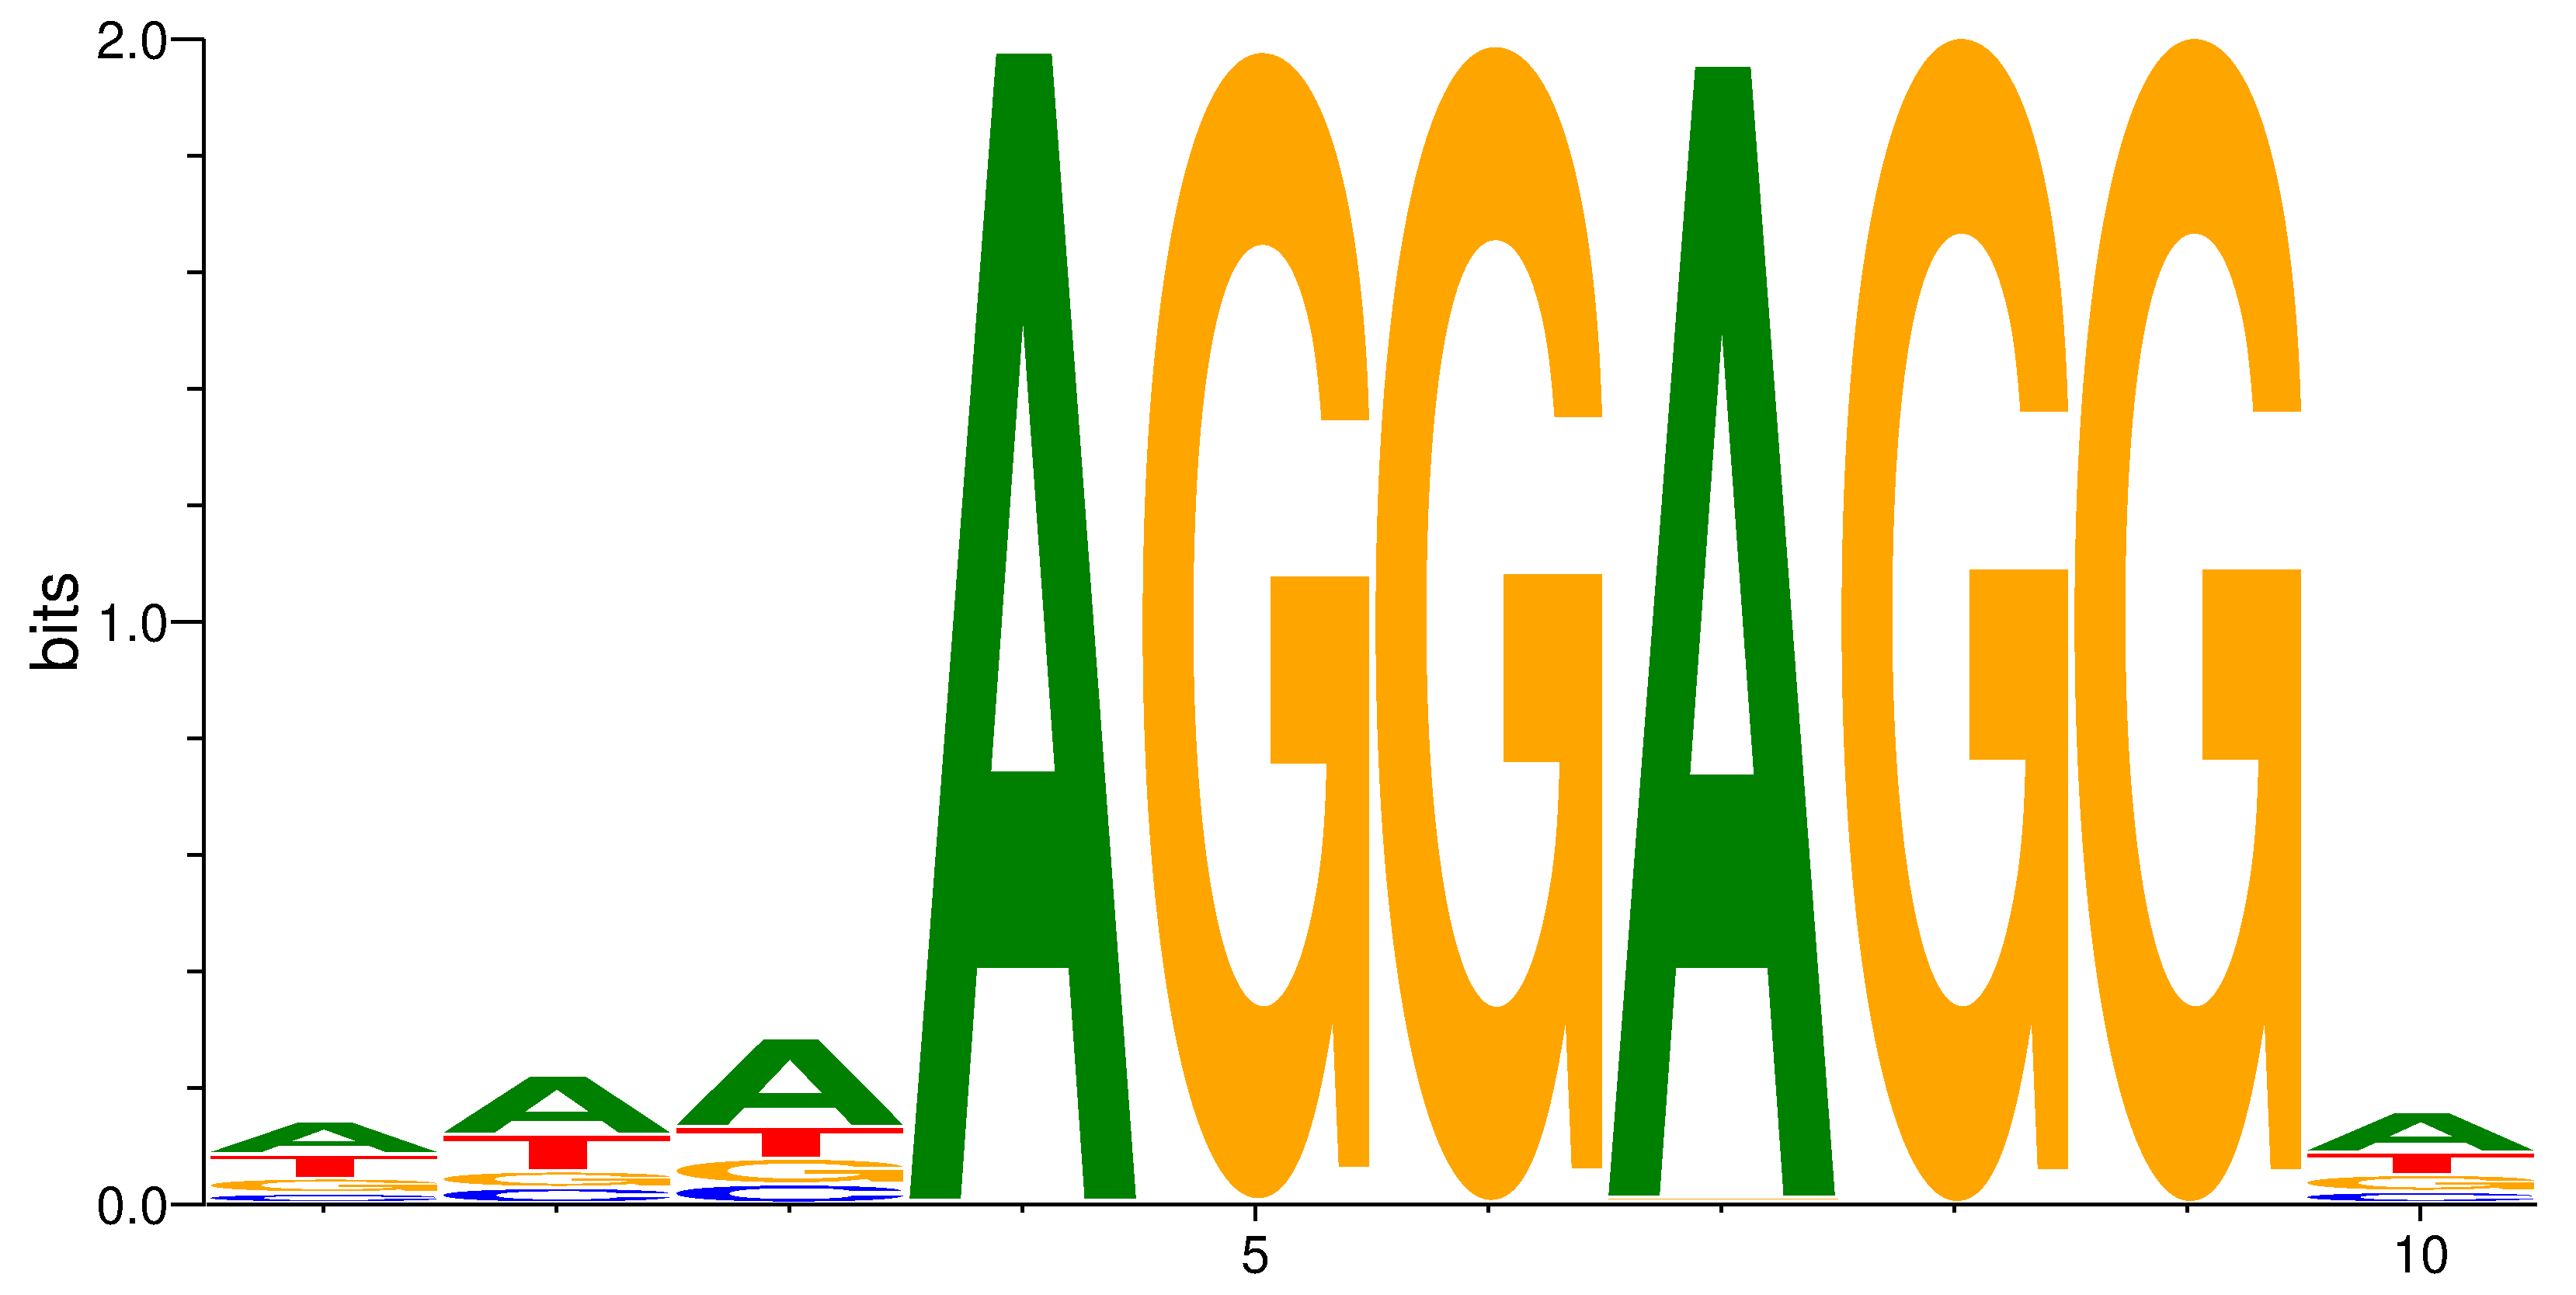

In [15]:
# Run the gibbs sampler:
promoter_pfm = GibbsMotifFinder(seqs,10 )
# Plot the final pfm that is generated: 
sl.seqlogo(sl.CompletePm(pfm = promoter_pfm.T))

---
# Challenge Yourself
Now that you potentially have a working skeleton of the project, try to work with the new NRF1 ChIP-seq data: `data/nrf1_gibbs.fa`.

Upon inspection, you will see that it is just a FASTA file. Since it is a FASTA file, you already have an example in the code above on how to access FASTA files. It is up to you to do the correct data ingest with it, though.

---
# NRF1 Driver Program
Modify the code below and test your Gibbs Sampler.

In [10]:
# Here we test your Gibbs sampler.
# You do not need to edit this or the section below. This is the Driver program

#read promoters, store in a list of strings
nrf1_file="data/nrf1_gibbs.fa"

nrf1_peaks = [seq for name, seq in (data_readers.get_fasta(nrf1_file))]

#TODO: Data ingest of nrf1_peaks

# Run the gibbs sampler:
nrf1_pfm = GibbsMotifFinder(nrf1_peaks, 10)

# Plot the final pfm that is generated: 
sl.seqlogo(sl.CompletePm(pfm = nrf1_pfm.T))

This is loop 0, with IC 0.1299611266128946 at time 0.7687816619873047


NameError: name 'motif' is not defined

In [ ]:
 #GCGCATGCGC

help(data_readers)